In [1]:
# Author: Brent Artuch
# Date: 11-12-2025
# Couse: PHY-4730

# Quatum Teleportation

In [5]:
# ! pip install qiskit_ibm_runtime

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, SamplerV2, Session
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.result import marginal_distribution

In [3]:
# Part 1: QT Unentangled Qubit 
def Quantum_Teleportation(basis_measurement):
    q_0 = QuantumRegister(1, "q_0")
    q_1 = QuantumRegister(1, "q_1")
    q_2 = QuantumRegister(1, "q_2")
    a = ClassicalRegister(1, "a")
    b = ClassicalRegister(1, "b")
    result = ClassicalRegister(1, "Result")
    
    # Create the quantum circuit
    qt_circuit = QuantumCircuit(q_0,q_1,q_2,a,b,result, name='QT')
    
    # Create bell state of q_1 and q_2
    qt_circuit.h(q_1)
    qt_circuit.cx(1,2)
    
    qt_circuit.barrier()
    
    # Define the data gate
    data_circuit = QuantumCircuit(1, name='data')
    data_circuit.h(0)
    data_circuit.s(0)
    data_circuit.h(0)
    data_circuit.t(0)
    data_circuit.h(0)
    data_circuit.t(0)
    data_circuit.h(0)
    
    # Convert the circuit to a Gate object and add to circuit
    data_gate = data_circuit.to_gate()
    qt_circuit.append(data_gate, [0])
    
    qt_circuit.barrier()

    # Apply bell measurement of q_0 and q_1
    qt_circuit.cx(0,1)
    qt_circuit.h(q_0)
    
    qt_circuit.barrier()
    
    # Measure q_0 and q_1 and store results in classical bits
    qt_circuit.measure(q_1,a)
    qt_circuit.measure(q_0,b)
    
    qt_circuit.barrier()
    
    # Conditionally apply gates
    with qt_circuit.if_test((a, 1)):
        qt_circuit.x(q_2)
    with qt_circuit.if_test((b, 1)):
        qt_circuit.z(q_2)
    
    qt_circuit.barrier()

    # Apply required gates for desired basis measurement
    if basis_measurement == "X": 
        qt_circuit.h(q_2)

    if basis_measurement == "Y": 
        qt_circuit.sdg(q_2)
        qt_circuit.h(q_2)

    if basis_measurement == "Z": 
        pass
    
    qt_circuit.measure(q_2,result)
    
    return qt_circuit

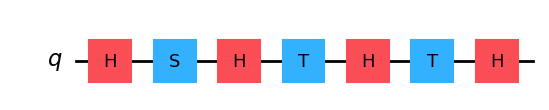

In [4]:
# Display the data gate contents
data_circuit = QuantumCircuit(1, name='data')
data_circuit.h(0)
data_circuit.s(0)
data_circuit.h(0)
data_circuit.t(0)
data_circuit.h(0)
data_circuit.t(0)
data_circuit.h(0)

display(data_circuit.draw('mpl'))

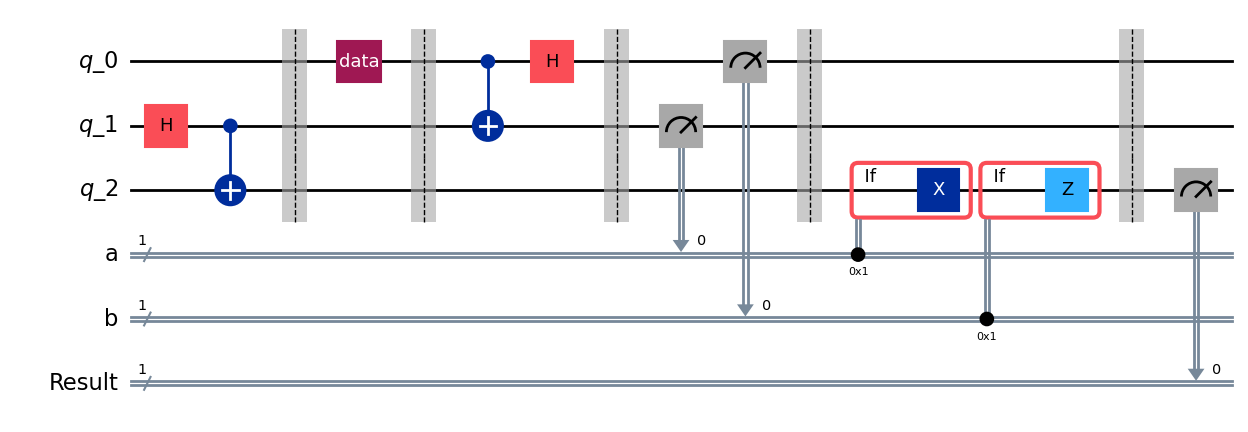

In [ ]:
# Z-basis measurement
z_circuit = Quantum_Teleportation("Z")

# Draw the circuit
display(z_circuit.draw('mpl'))

In [20]:
# Simulate the circuit
def simulate_circuit(circuit):
    simulator = AerSimulator()
    compiled_circuit = transpile(circuit, simulator)
    job = simulator.run(compiled_circuit, shots=1000)
    result = job.result()
    counts = result.get_counts(compiled_circuit)

    return counts


Measurement results (counts): {'1 0 0': 162, '0 0 0': 74, '0 1 0': 60, '0 0 1': 54, '1 1 0': 196, '1 0 1': 197, '0 1 1': 61, '1 1 1': 196}


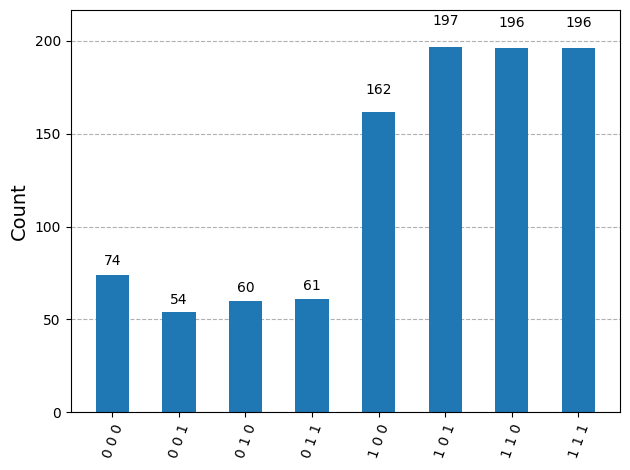

In [ ]:
# Print and visualize the results.
counts = simulate_circuit(z_circuit)
print("\nMeasurement results (counts):", counts)
plot_histogram(counts)

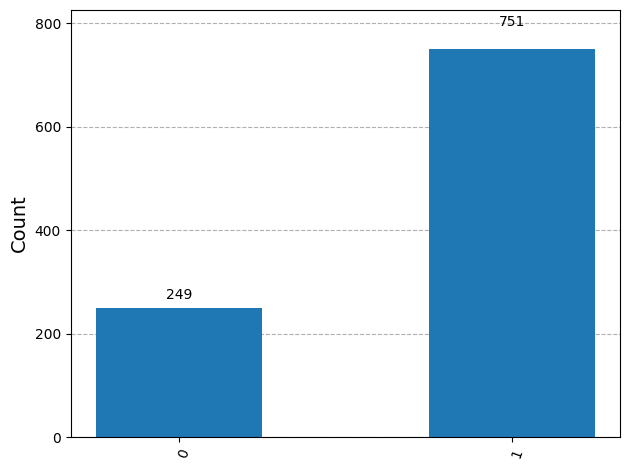

In [5]:
# Results of only Result register
filtered_statistics = marginal_distribution(counts, [2])
display(plot_histogram(filtered_statistics))

In [23]:
def get_backend(quantum_processor):
    service = QiskitRuntimeService(channel="ibm_quantum_platform", token="de0o7E_m88l7Db4tjnDevDM63m1LdkenOncjvD5xysuT", instance='crn:v1:bluemix:public:quantum-computing:us-east:a/692e3c7484ee484aa954cb431fcbe3fd:017bb3ed-5aab-45bf-a7a1-bc2fe7b182a9::')
    #service.save_account(channel="ibm_quantum_platform", token="de0o7E_m88l7Db4tjnDevDM63m1LdkenOncjvD5xysuT", instance='crn:v1:bluemix:public:quantum-computing:us-east:a/692e3c7484ee484aa954cb431fcbe3fd:017bb3ed-5aab-45bf-a7a1-bc2fe7b182a9::', overwrite=True)
    backend = service.backend(quantum_processor) 
    print(f"Running on backend: {backend.name}")

    return backend

In [54]:
def transpile_and_run(circuit):
    # Transpile
    backend = get_backend("ibm_torino")  
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)
    
    # Run On Quantum Computer
    sampler = SamplerV2(backend)
    job = sampler.run([isa_circuit], shots=1000)
    result = job.result()

    return job, result

In [8]:
job, result = transpile_and_run(z_circuit)
# Check on job progress 
job.status()

'DONE'

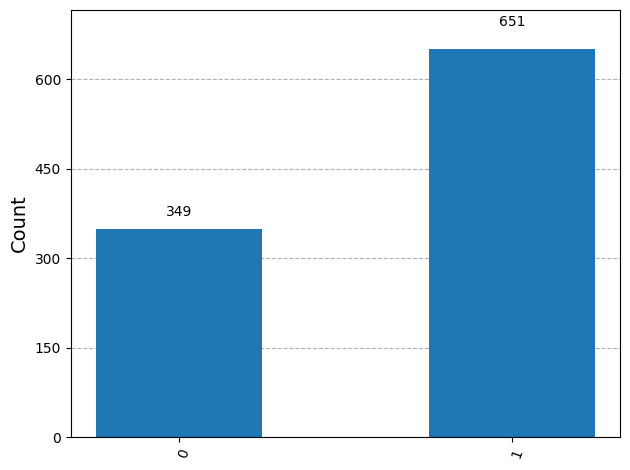

In [9]:
# Z-basis Results (Result Classical Register)
counts = result[0].data.Result.get_counts()
plot_histogram(counts)

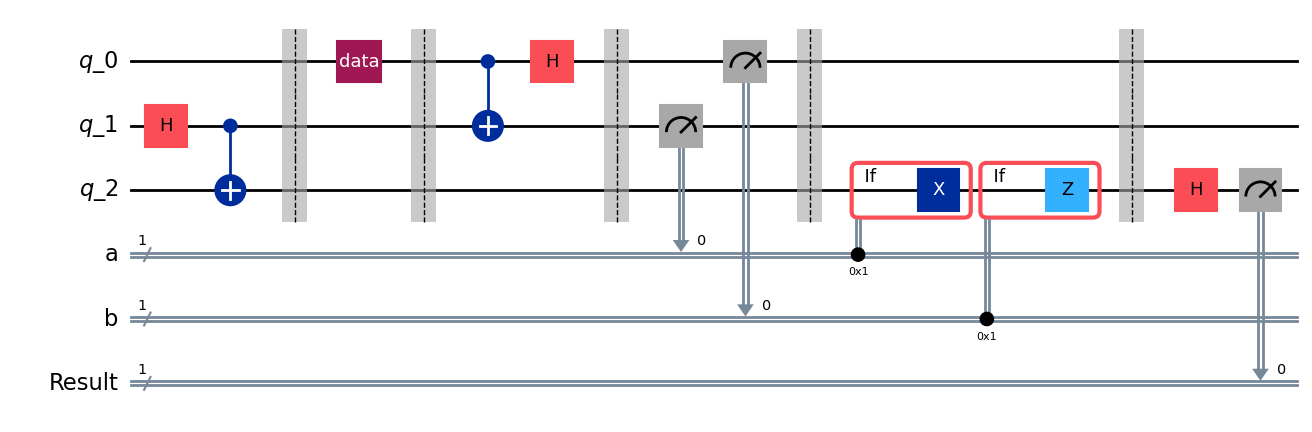

In [14]:
# X-basis measurement
x_circuit = Quantum_Teleportation("X")

# Draw the circuit
display(x_circuit.draw('mpl'))


Measurement results (counts): {'1 0 0': 40, '1 1 0': 33, '1 0 1': 36, '1 1 1': 32, '0 1 1': 212, '0 0 1': 229, '0 0 0': 201, '0 1 0': 217}


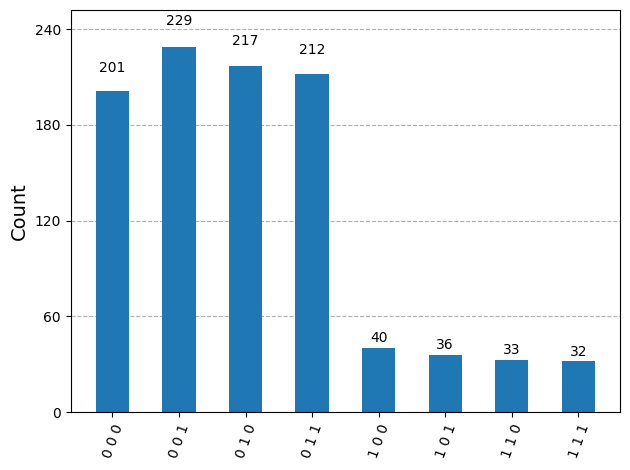

In [17]:
# Print and visualize the results.
counts = simulate_circuit(x_circuit)
print("\nMeasurement results (counts):", counts)
plot_histogram(counts)

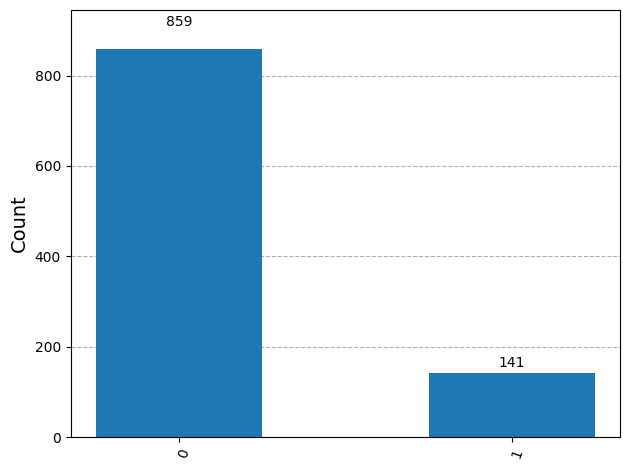

In [18]:
# Results of only Result register
filtered_statistics = marginal_distribution(counts, [2])
display(plot_histogram(filtered_statistics))

In [22]:
job, result = transpile_and_run(x_circuit)
# Check on job progress 
job.status()

qiskit_runtime_service._discover_account:WARNING:2025-11-13 20:46:28,428: Loading account with the given token. A saved account will not be used.


Running on backend: ibm_torino


'DONE'

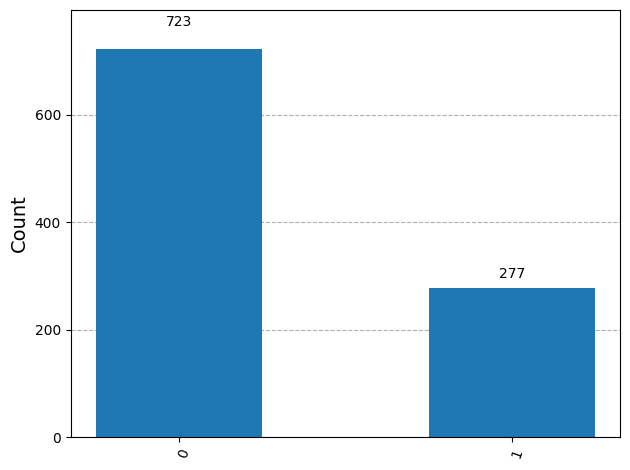

In [23]:
# X-basis Results (Result Classical Register)
counts = result[0].data.Result.get_counts()
plot_histogram(counts)

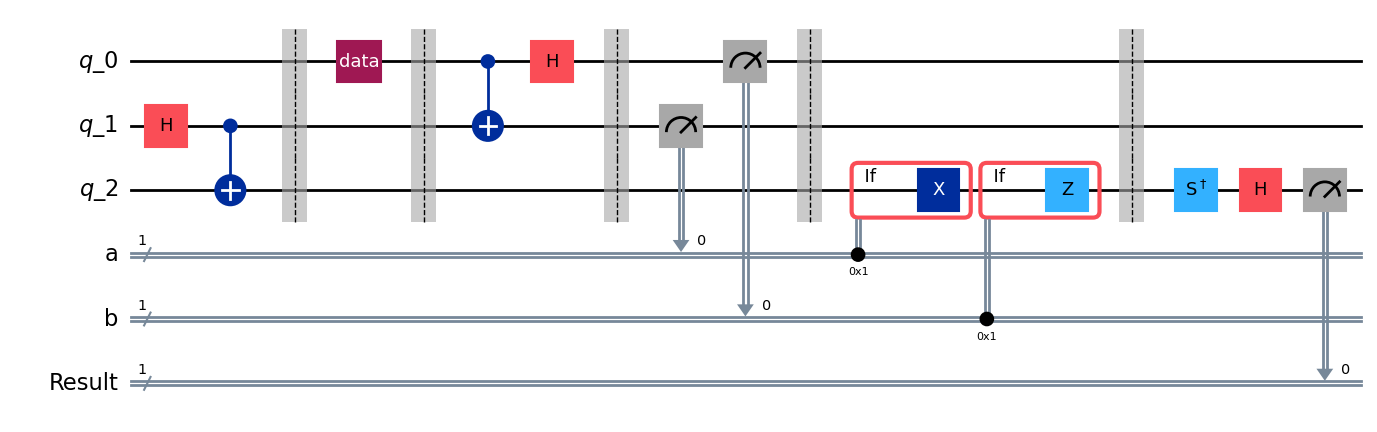

In [27]:
# Y-basis measurement
y_circuit = Quantum_Teleportation("Y")

# Draw the circuit
display(y_circuit.draw('mpl'))


Measurement results (counts): {'1 0 1': 189, '1 1 0': 169, '0 0 1': 59, '0 1 0': 72, '0 0 0': 70, '0 1 1': 54, '1 1 1': 181, '1 0 0': 206}


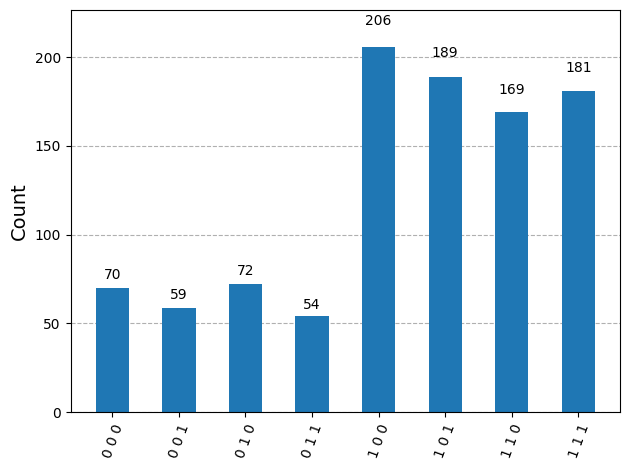

In [28]:
# Print and visualize the results.
counts = simulate_circuit(y_circuit)
print("\nMeasurement results (counts):", counts)
plot_histogram(counts)

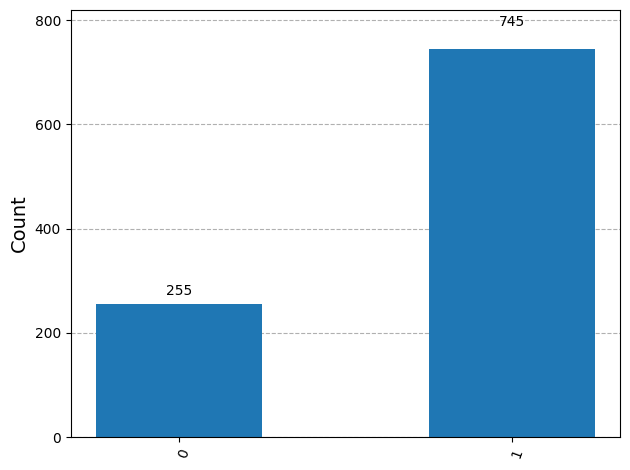

In [29]:
# Results of only Result register
filtered_statistics = marginal_distribution(counts, [2])
display(plot_histogram(filtered_statistics))

In [30]:
job, result = transpile_and_run(y_circuit)
# Check on job progress 
job.status()

qiskit_runtime_service._discover_account:WARNING:2025-11-13 21:04:59,698: Loading account with the given token. A saved account will not be used.


Running on backend: ibm_torino


'DONE'

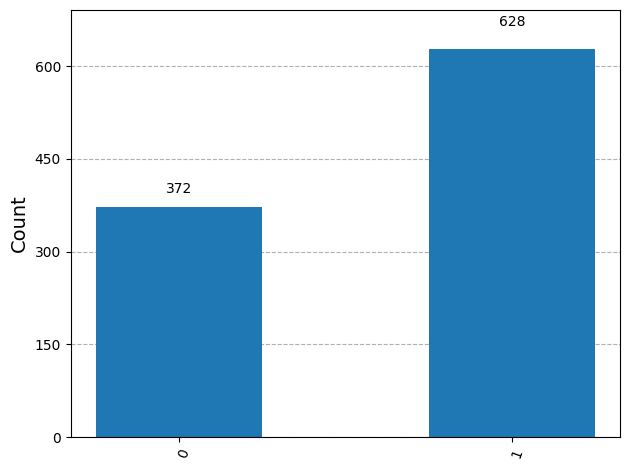

In [31]:
# Y-basis Results (Result Classical Register)
counts = result[0].data.Result.get_counts()
plot_histogram(counts)

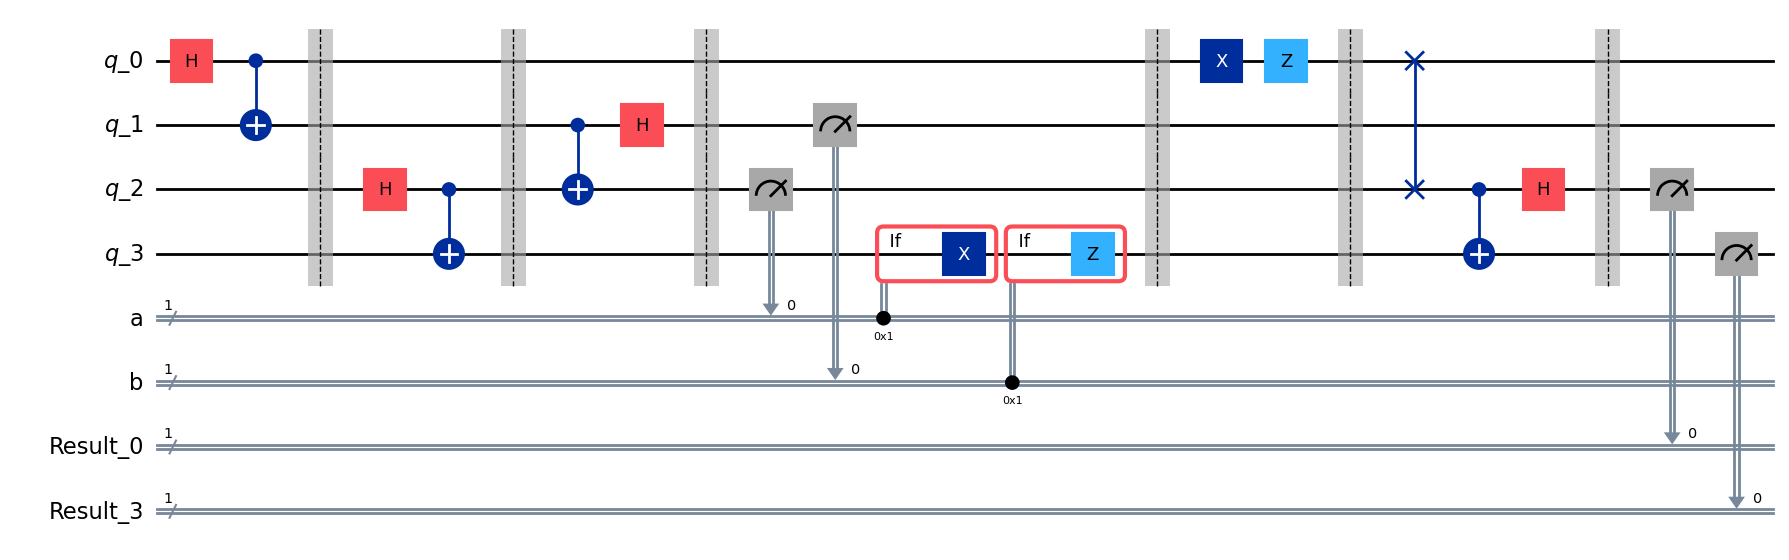

In [104]:
# Part 2: Entanglement Swapping
q_0 = QuantumRegister(1, "q_0")
q_1 = QuantumRegister(1, "q_1")
q_2 = QuantumRegister(1, "q_2")
q_3 = QuantumRegister(1, "q_3")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
result_0 = ClassicalRegister(1, "Result_0")
result_3 = ClassicalRegister(1, "Result_3")

es_circuit = QuantumCircuit(q_0,q_1,q_2,q_3,a,b,result_0,result_3, name='ES')

# Create Phi Plus state between q_0 and q_1
es_circuit.h(q_0)
es_circuit.cx(0,1)


es_circuit.barrier()

# Create Phi Plus state between q_2 and q_3
es_circuit.h(q_2)
es_circuit.cx(2,3)

es_circuit.barrier()

# Apply Bell measurement to q_1 and q_2
es_circuit.cx(1,2)
es_circuit.h(q_1)

es_circuit.barrier()

# Measure q_1 and q_2 and store results in classical bits
es_circuit.measure(q_2,a)
es_circuit.measure(q_1,b)


# Conditionally apply gates
with es_circuit.if_test((a, 1)):
    es_circuit.x(q_3)
with es_circuit.if_test((b, 1)):
    es_circuit.z(q_3)

es_circuit.barrier()

# Create Psi Minus state between q_0 and q_1
es_circuit.x(q_0)
es_circuit.z(q_0)

es_circuit.barrier()

es_circuit.swap(0,2)

# Apply Bell measurement to q_1 and q_2
es_circuit.cx(2,3)
es_circuit.h(q_2)

es_circuit.barrier()

es_circuit.measure(q_2,result_0)
es_circuit.measure(q_3,result_3)

display(es_circuit.draw('mpl'))


Measurement results (counts): {'1 1 1 0': 245, '1 1 0 0': 246, '1 1 0 1': 255, '1 1 1 1': 254}


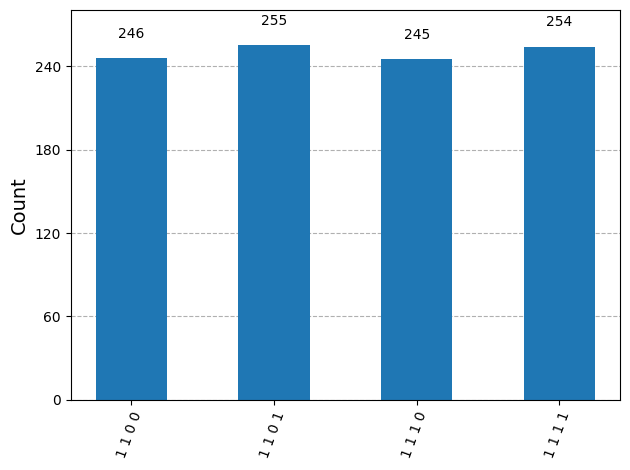

In [105]:
# Print and visualize the results.
simulated_counts = simulate_circuit(es_circuit)
print("\nMeasurement results (counts):", simulated_counts)
plot_histogram(simulated_counts)

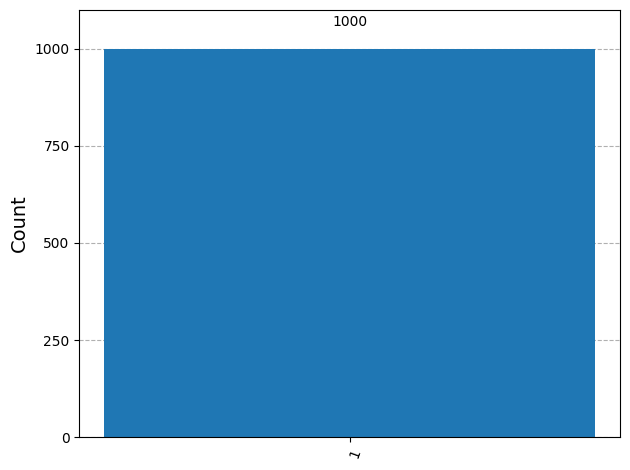

In [106]:
# Results of only Result register
filtered_statistics = marginal_distribution(simulated_counts, [2])
display(plot_histogram(filtered_statistics))

In [107]:
job, result = transpile_and_run(es_circuit)
# Check on job progress 
job.status()

qiskit_runtime_service._discover_account:WARNING:2025-11-16 19:07:07,787: Loading account with the given token. A saved account will not be used.


Running on backend: ibm_torino


'DONE'

PrimitiveResult([SamplerPubResult(data=DataBin(a=BitArray(<shape=(), num_shots=1000, num_bits=1>), b=BitArray(<shape=(), num_shots=1000, num_bits=1>), Result_0=BitArray(<shape=(), num_shots=1000, num_bits=1>), Result_3=BitArray(<shape=(), num_shots=1000, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-11-17 00:07:15', stop='2025-11-17 00:07:16', size=1000>)])}, 'version': 2})


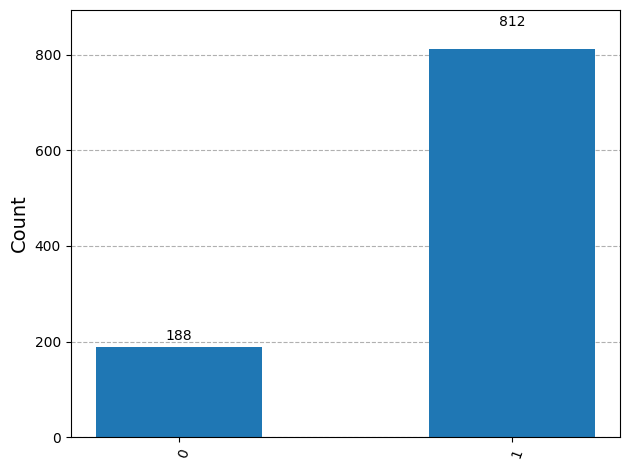

In [108]:
# q_0 Results (Result_0 Classical Register)
counts = result[0].data.Result_0.get_counts()
print(result)
plot_histogram(counts)

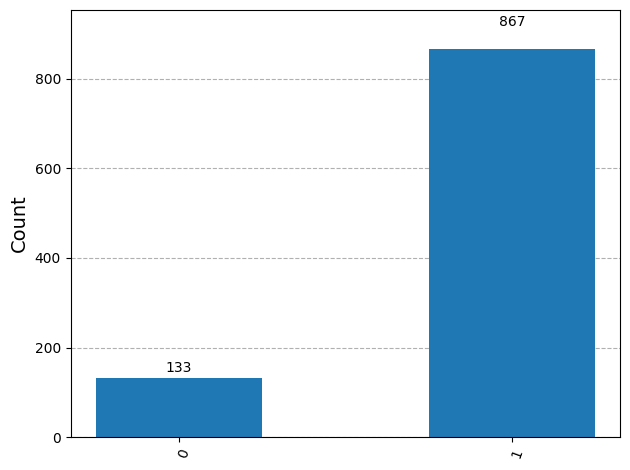

In [109]:
# q_3 Results (Result_3 Classical Register)
counts = result[0].data.Result_3.get_counts()

plot_histogram(counts)

In [88]:
import numpy as np

rho = np.array([[0.013358, 0, 0, 0],
                [0, 0.101942, 0, 0],
                [0, 0, 0.1025, 0],
                [0, 0, 0, 0.7822]])


rho_squared = rho**2
trace = np.trace(rho_squared)
round(float(trace),3)

0.633

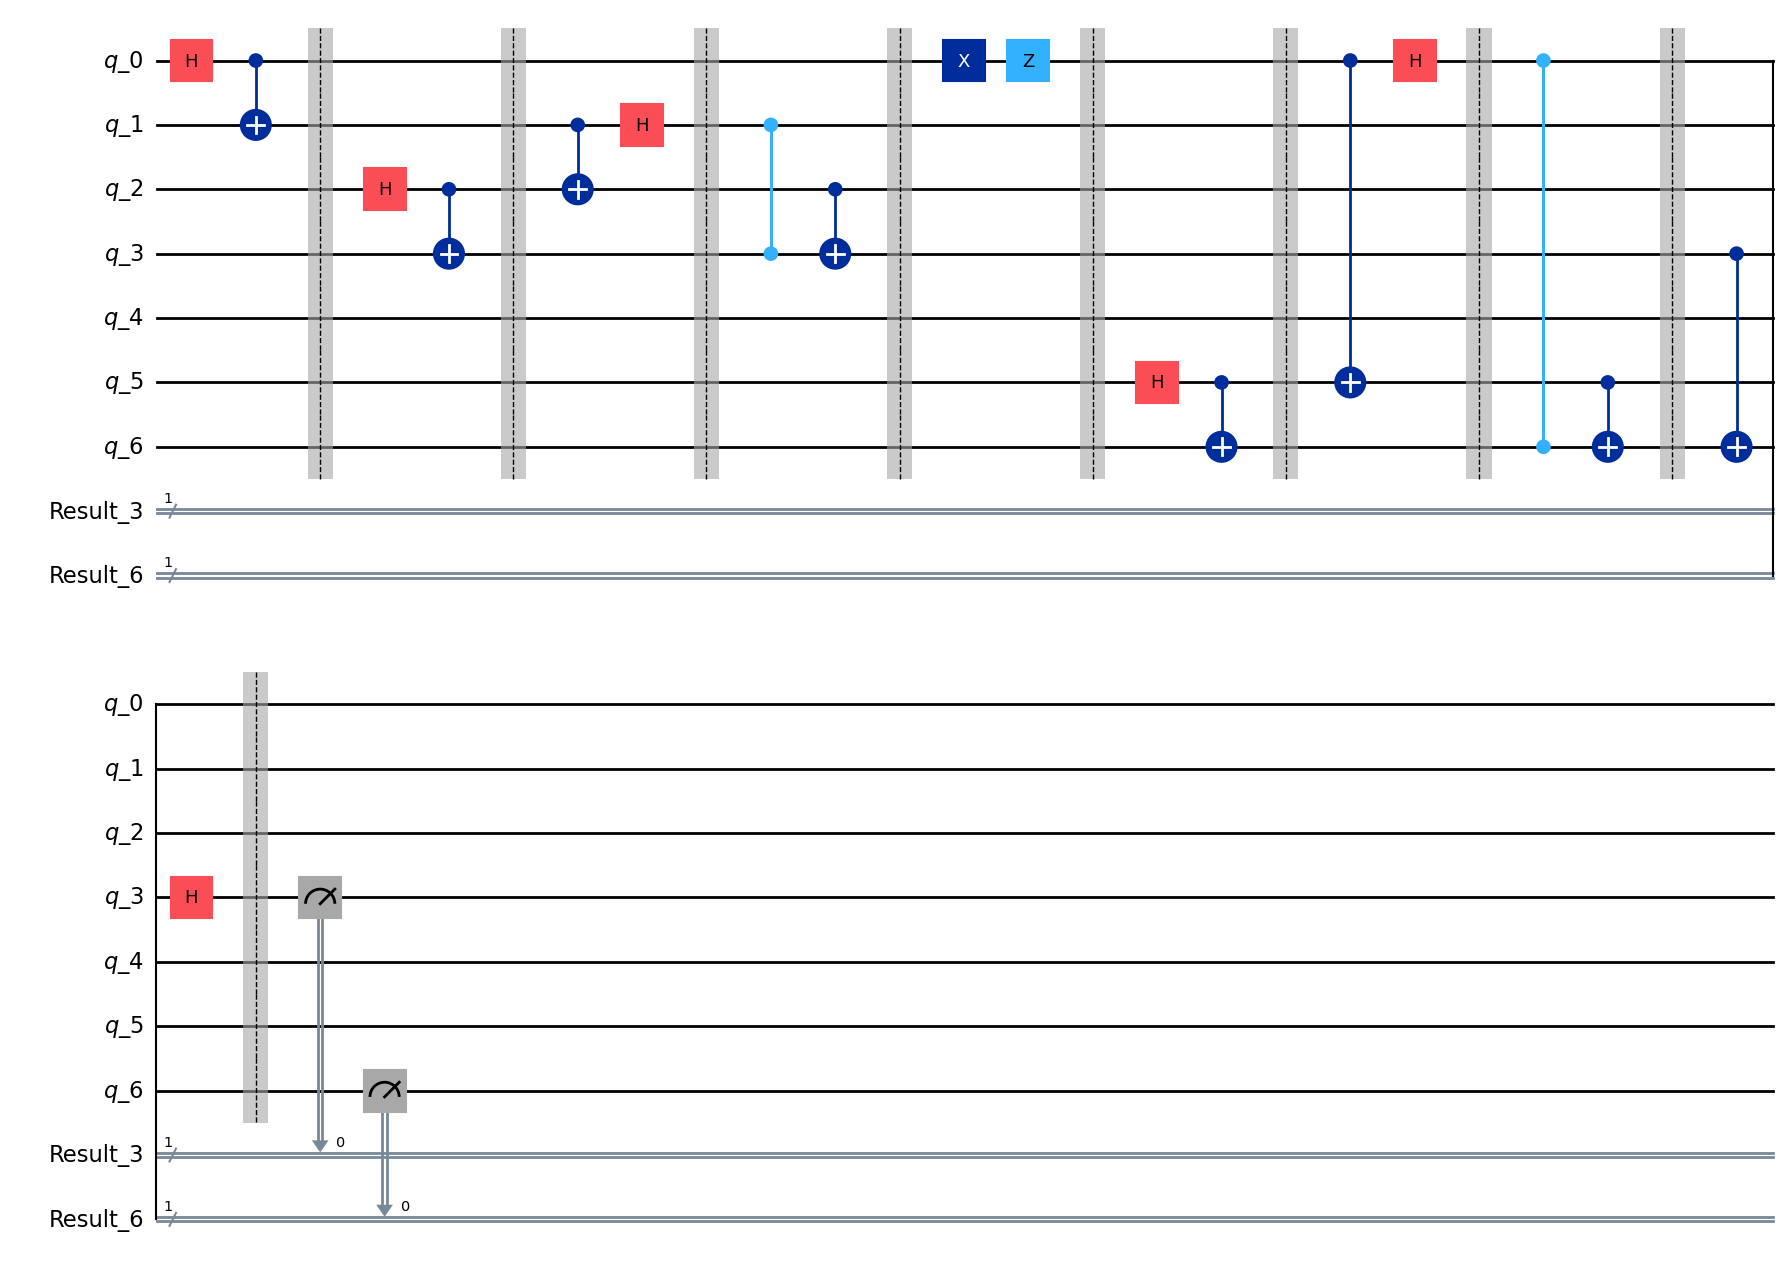

In [120]:
# Part 3: Bell Pair Teleportation
q_0 = QuantumRegister(1, "q_0")
q_1 = QuantumRegister(1, "q_1")
q_2 = QuantumRegister(1, "q_2")
q_3 = QuantumRegister(1, "q_3")
q_4 = QuantumRegister(1, "q_4")
q_5 = QuantumRegister(1, "q_5")
q_6 = QuantumRegister(1, "q_6")
result_3 = ClassicalRegister(1, "Result_3")
result_6 = ClassicalRegister(1, "Result_6")

bpt_circuit = QuantumCircuit(q_0,q_1,q_2,q_3,q_4,q_5,q_6,result_3,result_6, name='BPT')

# Create Phi Plus state between q_0 and q_1
bpt_circuit.h(q_0)
bpt_circuit.cx(0,1)

bpt_circuit.barrier()

# Create Phi Plus state between q_2 and q_3
bpt_circuit.h(q_2)
bpt_circuit.cx(2,3)

bpt_circuit.barrier()

# Apply Bell measurement to q_1 and q_2
bpt_circuit.cx(1,2)
bpt_circuit.h(q_1)

bpt_circuit.barrier()

# Conditional operations on q_3
bpt_circuit.cz(1,3)
bpt_circuit.cx(2,3)

bpt_circuit.barrier()

# Create Psi Minus state between q_0 and q_1
bpt_circuit.x(q_0)
bpt_circuit.z(q_0)

bpt_circuit.barrier()

# Create Phi Plus state between q_5 and q_6
bpt_circuit.h(q_5)
bpt_circuit.cx(5,6)

bpt_circuit.barrier()

# Apply Bell measurement to q_0 and q_5
bpt_circuit.cx(0,5)
bpt_circuit.h(q_0)

bpt_circuit.barrier()

# Conditional operations on q_6
bpt_circuit.cz(0,6)
bpt_circuit.cx(5,6)

bpt_circuit.barrier()

# Apply Bell measurement to q_3 and q_6
bpt_circuit.cx(3,6)
bpt_circuit.h(q_3)

bpt_circuit.barrier()

bpt_circuit.measure(q_3,result_3)
bpt_circuit.measure(q_6,result_6)

display(bpt_circuit.draw('mpl'))


Measurement results (counts): {'1 1': 1000}


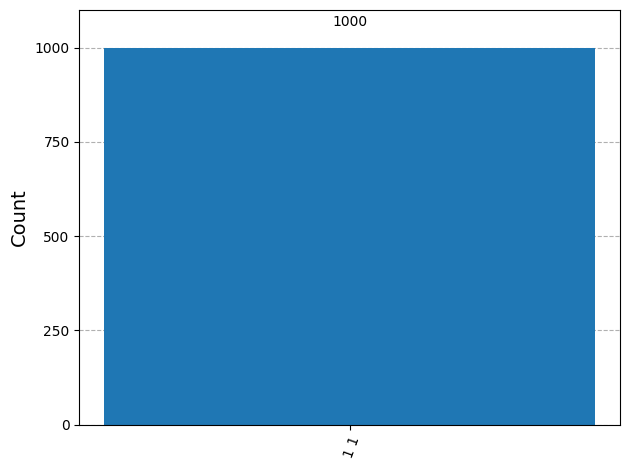

In [121]:
# Print and visualize the results.
simulated_counts = simulate_circuit(bpt_circuit)
print("\nMeasurement results (counts):", simulated_counts)
plot_histogram(simulated_counts)

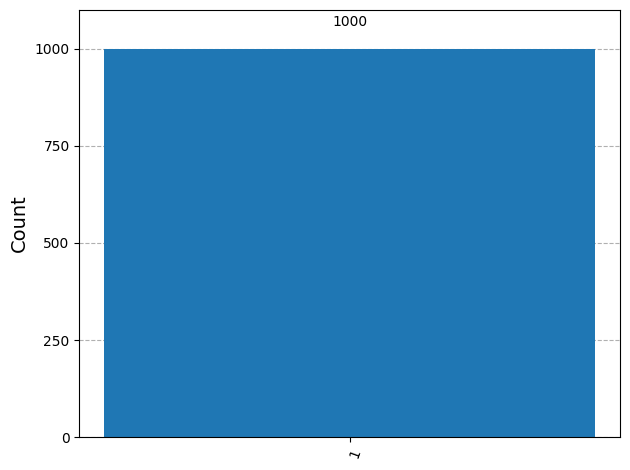

In [124]:
# Results of only Result_3 register
filtered_statistics = marginal_distribution(simulated_counts, [1])
display(plot_histogram(filtered_statistics))

In [125]:
job, result = transpile_and_run(bpt_circuit)
# Check on job progress 
job.status()

qiskit_runtime_service._discover_account:WARNING:2025-11-16 19:48:07,628: Loading account with the given token. A saved account will not be used.


Running on backend: ibm_torino


'DONE'

PrimitiveResult([SamplerPubResult(data=DataBin(Result_3=BitArray(<shape=(), num_shots=1000, num_bits=1>), Result_6=BitArray(<shape=(), num_shots=1000, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-11-17 00:48:16', stop='2025-11-17 00:48:18', size=1000>)])}, 'version': 2})


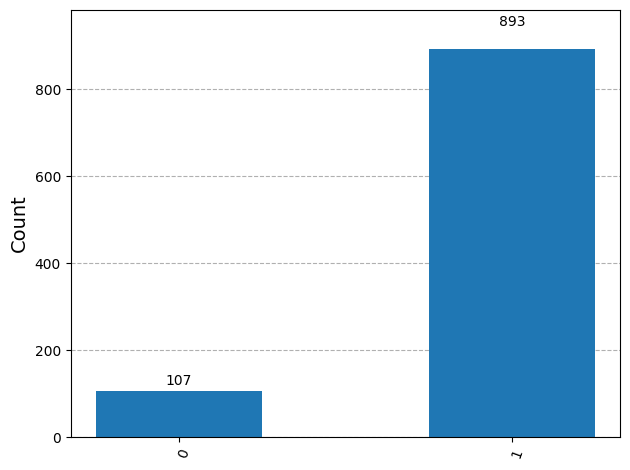

In [126]:
# q_3 Results (Result_3 Classical Register)
counts = result[0].data.Result_3.get_counts()
print(result)
plot_histogram(counts)

PrimitiveResult([SamplerPubResult(data=DataBin(Result_3=BitArray(<shape=(), num_shots=1000, num_bits=1>), Result_6=BitArray(<shape=(), num_shots=1000, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-11-17 00:48:16', stop='2025-11-17 00:48:18', size=1000>)])}, 'version': 2})


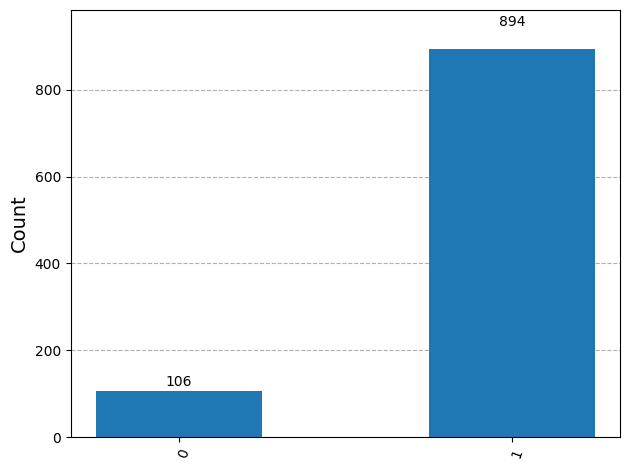

In [127]:
# q_6 Results (Result_6 Classical Register)
counts = result[0].data.Result_6.get_counts()
print(result)
plot_histogram(counts)

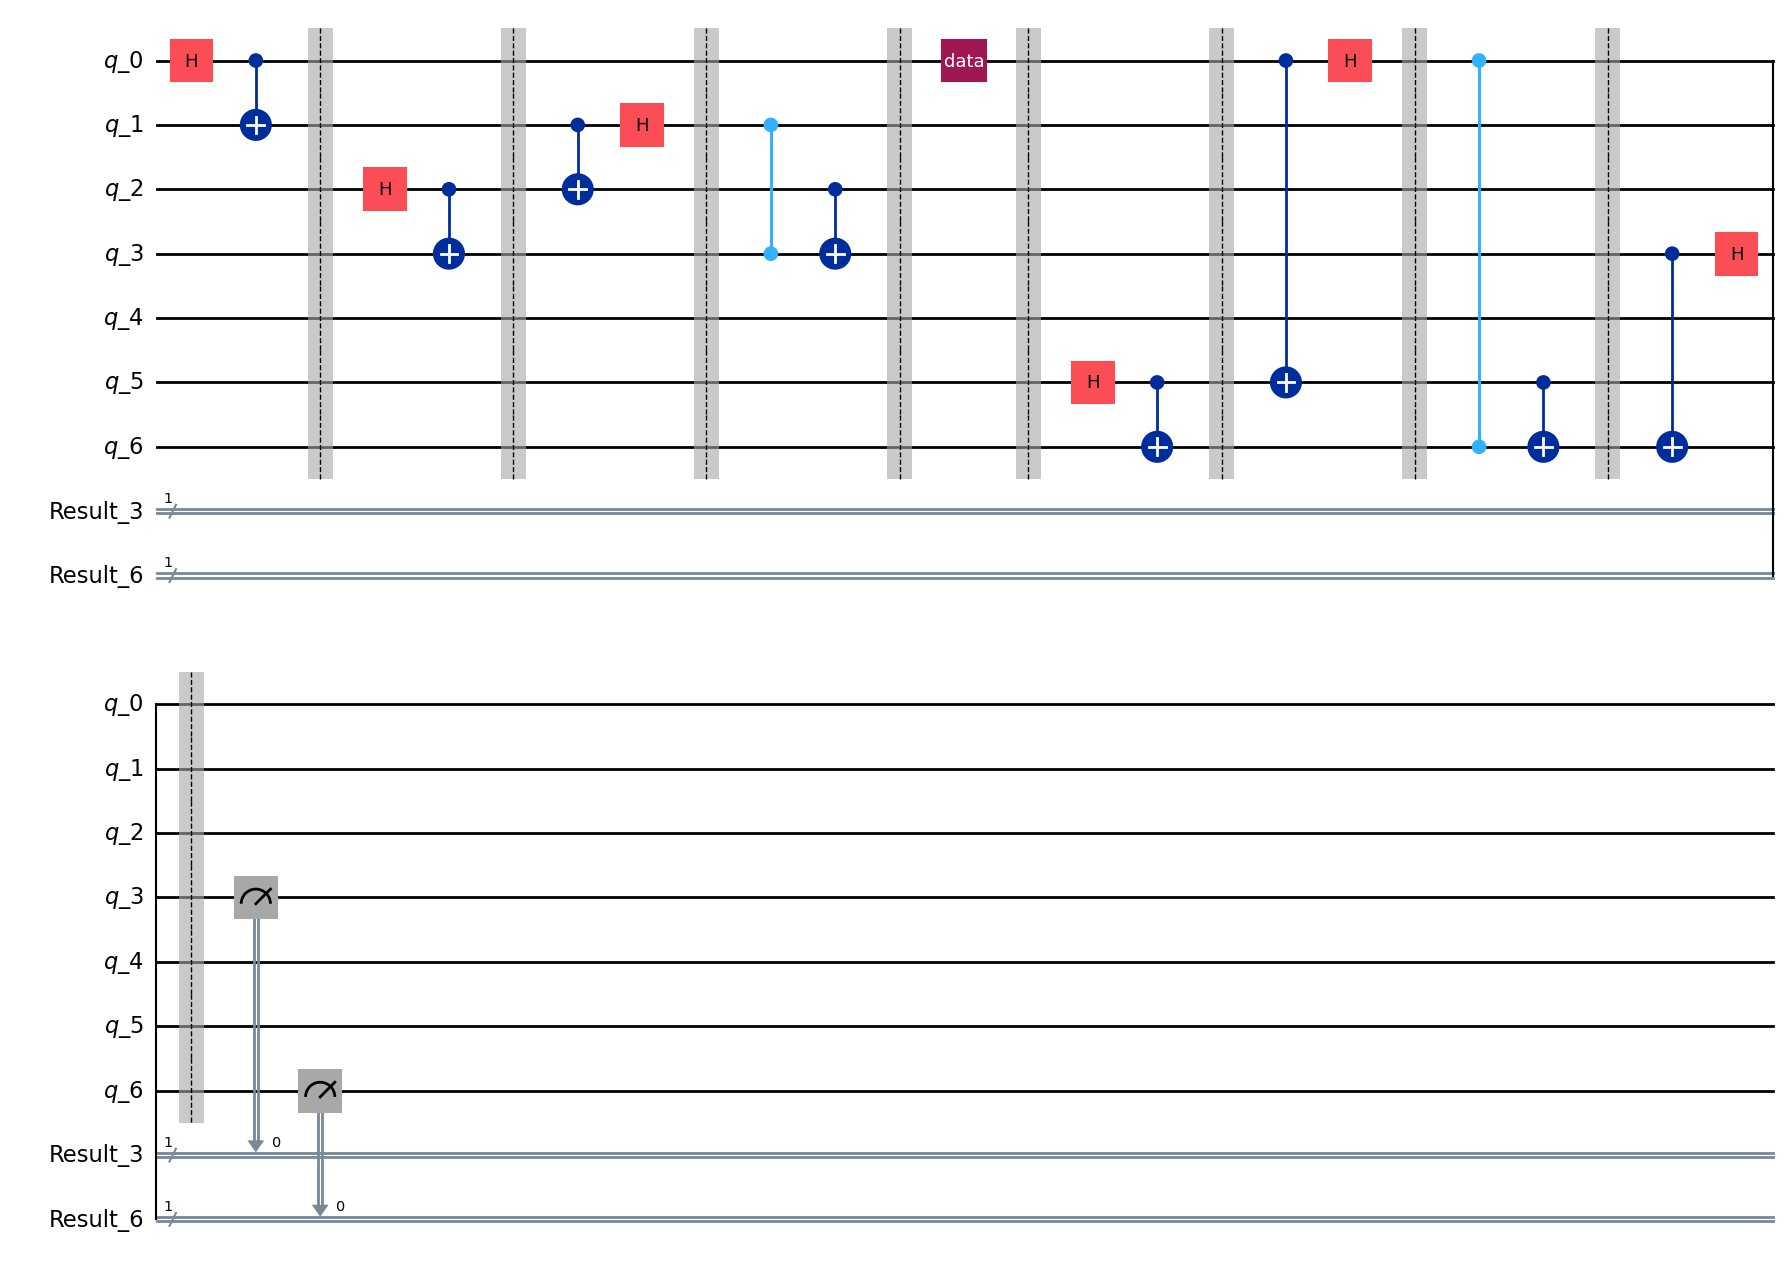

In [129]:
q_0 = QuantumRegister(1, "q_0")
q_1 = QuantumRegister(1, "q_1")
q_2 = QuantumRegister(1, "q_2")
q_3 = QuantumRegister(1, "q_3")
q_4 = QuantumRegister(1, "q_4")
q_5 = QuantumRegister(1, "q_5")
q_6 = QuantumRegister(1, "q_6")
result_3 = ClassicalRegister(1, "Result_3")
result_6 = ClassicalRegister(1, "Result_6")

bpt_circuit = QuantumCircuit(q_0,q_1,q_2,q_3,q_4,q_5,q_6,result_3,result_6, name='BPT')

# Create Phi Plus state between q_0 and q_1
bpt_circuit.h(q_0)
bpt_circuit.cx(0,1)

bpt_circuit.barrier()

# Create Phi Plus state between q_2 and q_3
bpt_circuit.h(q_2)
bpt_circuit.cx(2,3)

bpt_circuit.barrier()

# Apply Bell measurement to q_1 and q_2
bpt_circuit.cx(1,2)
bpt_circuit.h(q_1)

bpt_circuit.barrier()

# Conditional operations on q_3
bpt_circuit.cz(1,3)
bpt_circuit.cx(2,3)

bpt_circuit.barrier()

# Define the data gate
data_circuit = QuantumCircuit(1, name='data')
data_circuit.h(0)
data_circuit.s(0)
data_circuit.h(0)
data_circuit.t(0)
data_circuit.h(0)
data_circuit.t(0)
data_circuit.h(0)

# Convert the circuit to a Gate object and add to circuit
data_gate = data_circuit.to_gate()
bpt_circuit.append(data_gate, [0])

bpt_circuit.barrier()

# Create Phi Plus state between q_5 and q_6
bpt_circuit.h(q_5)
bpt_circuit.cx(5,6)

bpt_circuit.barrier()

# Apply Bell measurement to q_0 and q_5
bpt_circuit.cx(0,5)
bpt_circuit.h(q_0)

bpt_circuit.barrier()

# Conditional operations on q_6
bpt_circuit.cz(0,6)
bpt_circuit.cx(5,6)

bpt_circuit.barrier()

# Apply Bell measurement to q_3 and q_6
bpt_circuit.cx(3,6)
bpt_circuit.h(q_3)

bpt_circuit.barrier()

bpt_circuit.measure(q_3,result_3)
bpt_circuit.measure(q_6,result_6)

display(bpt_circuit.draw('mpl'))


Measurement results (counts): {'1 1': 15, '0 1': 147, '0 0': 116, '1 0': 722}


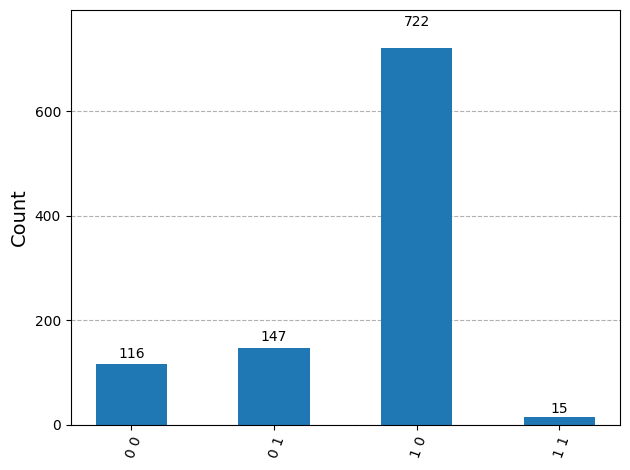

In [130]:
# Print and visualize the results.
simulated_counts = simulate_circuit(bpt_circuit)
print("\nMeasurement results (counts):", simulated_counts)
plot_histogram(simulated_counts)

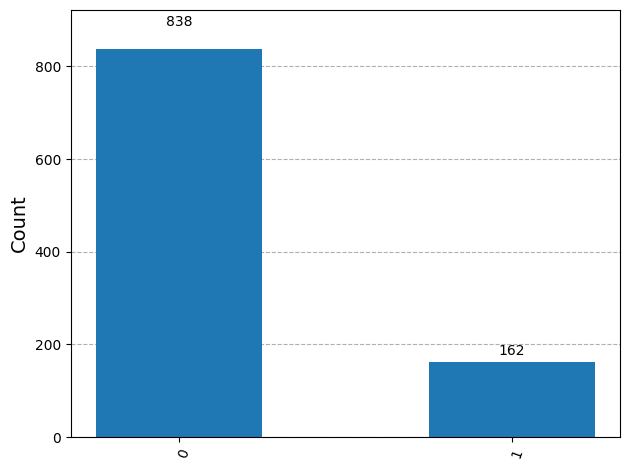

In [131]:
# Results of only Result_3 register
filtered_statistics = marginal_distribution(simulated_counts, [0])
display(plot_histogram(filtered_statistics))

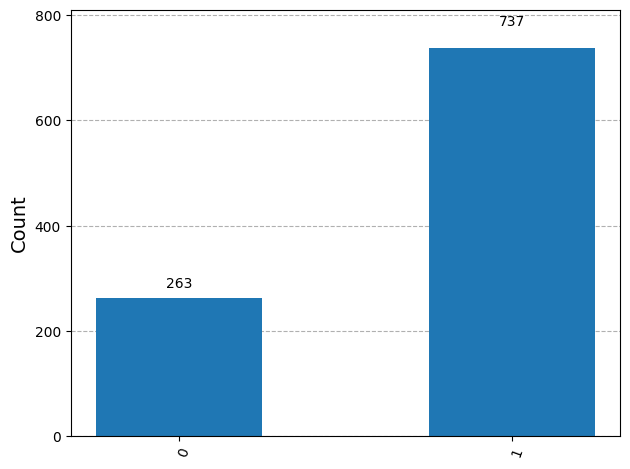

In [132]:
# Results of only Result_3 register
filtered_statistics = marginal_distribution(simulated_counts, [1])
display(plot_histogram(filtered_statistics))

In [133]:
job, result = transpile_and_run(bpt_circuit)
# Check on job progress 
job.status()

qiskit_runtime_service._discover_account:WARNING:2025-11-16 20:13:50,419: Loading account with the given token. A saved account will not be used.


Running on backend: ibm_torino


'DONE'

PrimitiveResult([SamplerPubResult(data=DataBin(Result_3=BitArray(<shape=(), num_shots=1000, num_bits=1>), Result_6=BitArray(<shape=(), num_shots=1000, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-11-17 01:13:58', stop='2025-11-17 01:14:01', size=1000>)])}, 'version': 2})


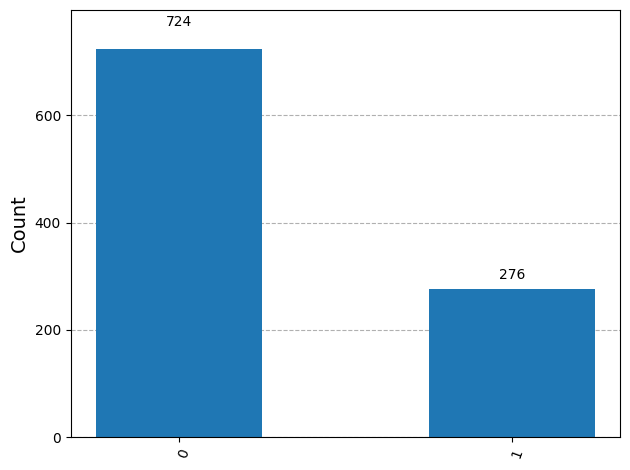

In [134]:
# q_3 Results (Result_3 Classical Register)
counts = result[0].data.Result_3.get_counts()
print(result)
plot_histogram(counts)

PrimitiveResult([SamplerPubResult(data=DataBin(Result_3=BitArray(<shape=(), num_shots=1000, num_bits=1>), Result_6=BitArray(<shape=(), num_shots=1000, num_bits=1>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-11-17 01:13:58', stop='2025-11-17 01:14:01', size=1000>)])}, 'version': 2})


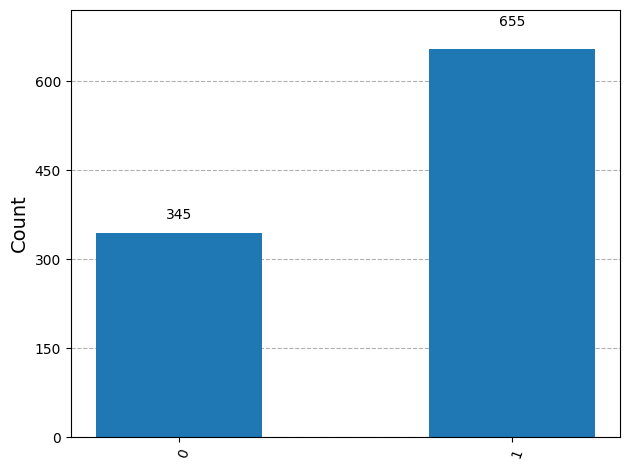

In [135]:
# q_6 Results (Result_6 Classical Register)
counts = result[0].data.Result_6.get_counts()
print(result)
plot_histogram(counts)